# Used Car Price Prediction - EDA, Data Cleaning & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("used_cars.csv")

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.shape

(4009, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [6]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [7]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [9]:
df.describe(include="object")


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [10]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for col in df.select_dtypes(include="object"):
    print("Column:", col)
    print("Unique values:", df[col].nunique())
    print("-------------------")

Column: brand
Unique values: 57
-------------------
Column: model
Unique values: 1898
-------------------
Column: milage
Unique values: 2818
-------------------
Column: fuel_type
Unique values: 7
-------------------
Column: engine
Unique values: 1146
-------------------
Column: transmission
Unique values: 62
-------------------
Column: ext_col
Unique values: 319
-------------------
Column: int_col
Unique values: 156
-------------------
Column: accident
Unique values: 2
-------------------
Column: clean_title
Unique values: 1
-------------------
Column: price
Unique values: 1569
-------------------


In [13]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [14]:
df["price"].head()

0    10300
1    38005
2    54598
3    15500
4    34999
Name: price, dtype: int64

In [15]:
df["milage"] = df["milage"].str.extract(r'([\d,]+)', expand=False)

df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
)

df["milage"] = pd.to_numeric(df["milage"], errors="coerce")

In [16]:
df["milage"].head(10)

0     51000
1     34742
2     22372
3     88900
4      9835
5    136397
6     84000
7    242000
8     23436
9     34000
Name: milage, dtype: int64

In [17]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [18]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [19]:
df.fillna("Unknown", inplace=True)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

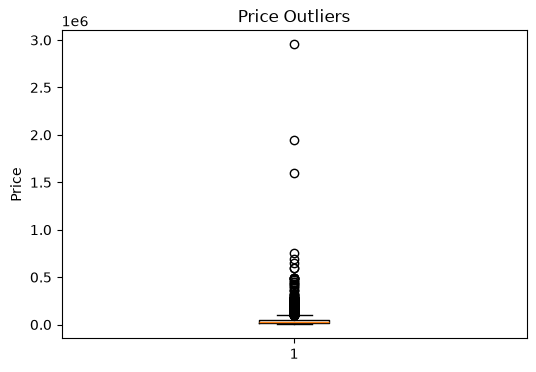

In [22]:
plt.figure(figsize=(6,4))

plt.boxplot(df["price"].dropna())

plt.title("Price Outliers")
plt.ylabel("Price")

plt.show()

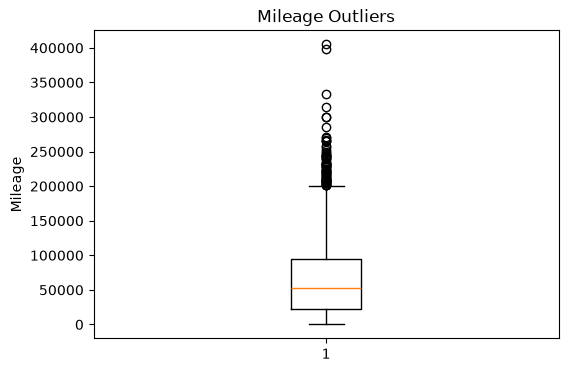

In [23]:
plt.figure(figsize=(6,4))

plt.boxplot(df["milage"].dropna())

plt.title("Mileage Outliers")
plt.ylabel("Mileage")

plt.show()

In [24]:
current_year = 2026

df["Car_Age"] = current_year - df["model_year"]

In [25]:
df["Price_per_Mile"] = np.where(
    df["milage"] > 0,
    df["price"] / df["milage"],
    np.nan
)

In [26]:
luxury_brands = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Lexus",
    "Porsche"
]

df["Luxury_Brand"] = (
    df["brand"]
    .isin(luxury_brands)
    .astype(int)
)

In [27]:
df["High_Mileage"] = (
    df["milage"] > 100000
).astype(int)

In [28]:
df["Vehicle_Age_Group"] = pd.cut(
    df["Car_Age"],
    bins=[0,5,10,20,100],
    labels=[
        "New",
        "Moderate",
        "Old",
        "Very Old"
    ]
)

In [29]:
df[
[
"Car_Age",
"Price_per_Mile",
"Luxury_Brand",
"High_Mileage",
"Vehicle_Age_Group"
]
].head()

,Car_Age,Price_per_Mile,Luxury_Brand,High_Mileage,Vehicle_Age_Group
0,13,0.201961,0,0,Old
1,5,1.093921,0,0,New
2,4,2.440461,1,0,New
3,11,0.174353,0,0,Old
4,5,3.558617,1,0,New


In [30]:
df.to_csv(
    "cleaned_used_cars.csv",
    index=False
)

In [31]:
cleaned = pd.read_csv("cleaned_used_cars.csv")

print(cleaned["price"].dtype)
print(cleaned["milage"].dtype)

cleaned.head()

int64
int64


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Car_Age,Price_per_Mile,Luxury_Brand,High_Mileage,Vehicle_Age_Group
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,0.201961,0,0,Old
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,1.093921,0,0,New
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598,4,2.440461,1,0,New
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,0.174353,0,0,Old
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999,5,3.558617,1,0,New


## Key Business Insights

1. Vehicle age has a significant impact on used car prices.

2. Cars with lower mileage generally have higher resale values.

3. Luxury brands tend to maintain better resale prices compared to regular brands.

4. Extremely high-priced vehicles appear as outliers and require careful handling before Machine Learning.

5. Engineered features provide additional information that can improve future price prediction models.